# Comprehensive Visualization - TITANIC DATASET

==================================================
This notebook demenostrate various visualization technique using matplotlib and seaborn 
with the titanic dataset = Perfect for practice ML visualization skills!

# Dataset Variables
    * Survived: 0 = Dead, 1 = Alive
    * Pclass: 1 = First class 2 = Second class 3 = Third class
    * Sex: Gender
    * Age: Passegers Age in numbers
    * SibSp: Number of siblings
    * Parch: Number of parents/children aboard
    * Fare: Passengers fare
    * Embarked: 
    

In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [20]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12,8)

In [21]:
df = pd.read_csv("./data/train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [22]:
print("="*80)
print("Titanic Dataset - Visualization")
print("="*80)
print(f"\nDataset shape: {df.shape}")
print(f"\nColumn Names: {df.columns.tolist()}")
print(f"\nData Types: {df.dtypes}")
print(f"\nMissing Values:\n: {df.isnull().sum()}")


Titanic Dataset - Visualization

Dataset shape: (891, 12)

Column Names: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Data Types: PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

Missing Values:
: PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [23]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# 1. UNIVARIATE ANALYSIS - single Variable Distrubution

## 1.1 Histogram - Distribution  of continous variables (Age)

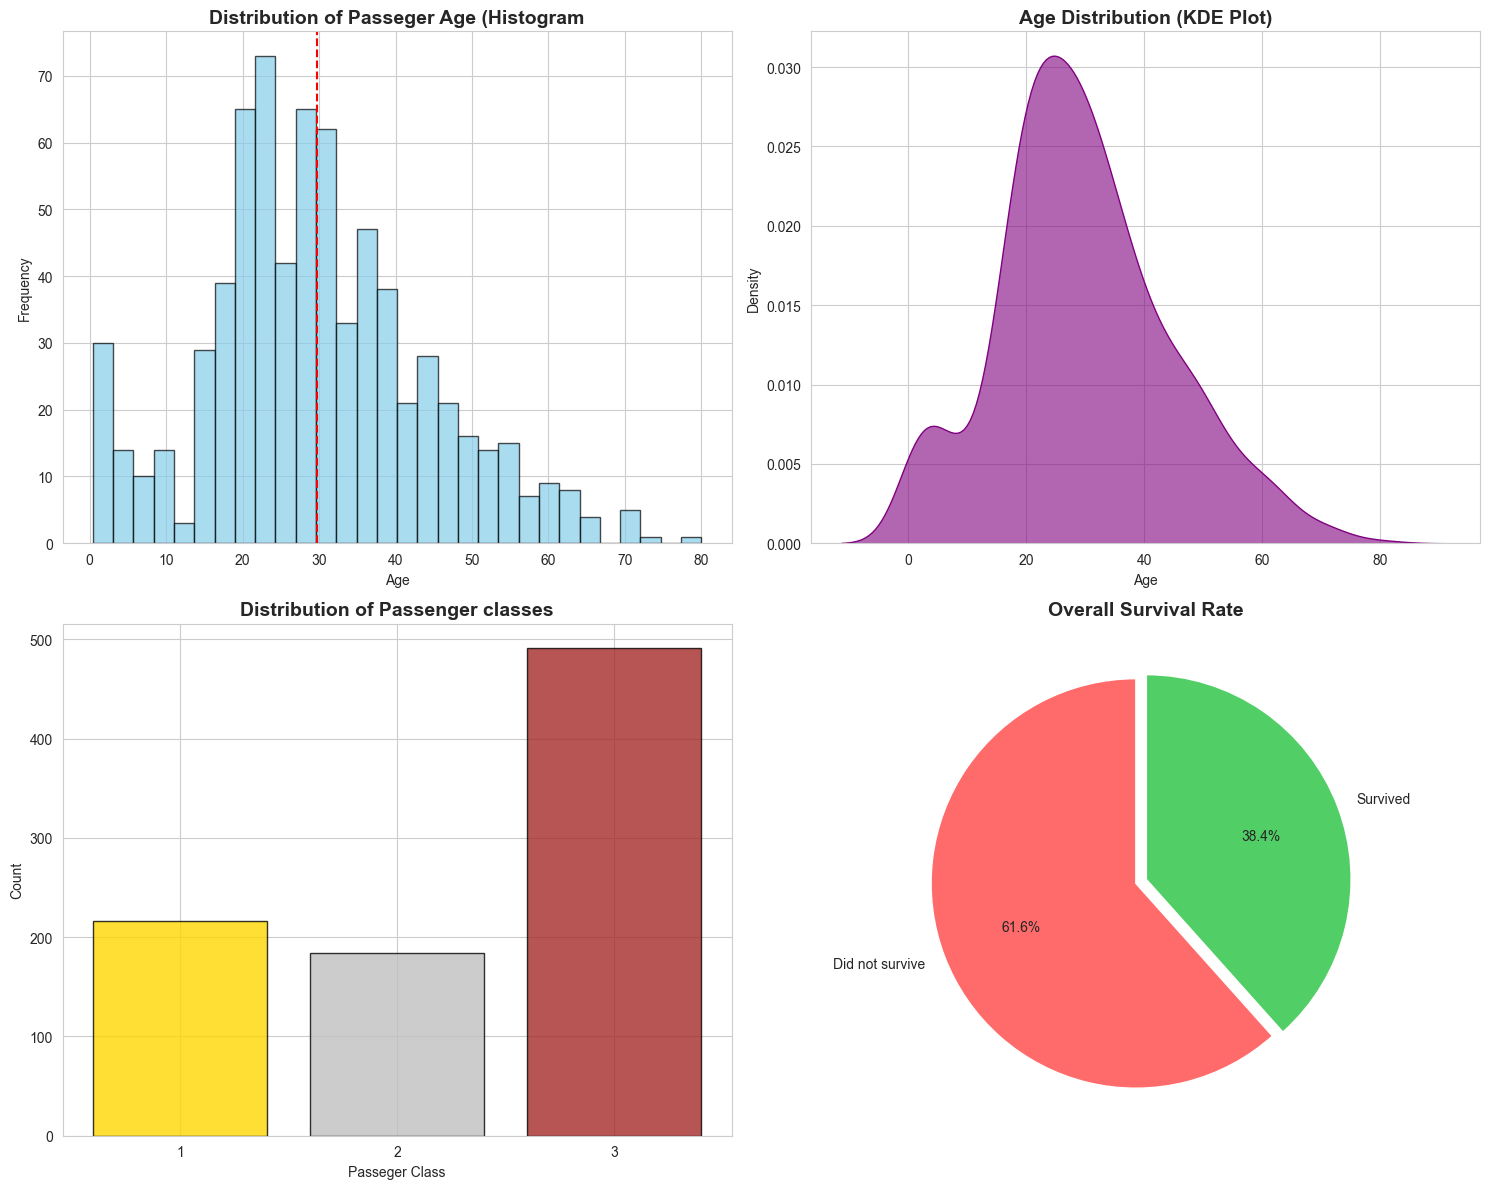

In [24]:
fig, axes = plt.subplots(2,2, figsize=(15,12))

# Basic Histogram
axes[0,0].hist(df['Age'].dropna(),bins=30,color='skyblue',edgecolor='black',alpha=0.7)
axes[0,0].set_xlabel("Age")
axes[0,0].set_ylabel("Frequency")
axes[0,0].set_title("Distribution of Passeger Age (Histogram", fontsize=14,fontweight='bold')
axes[0,0].axvline(df["Age"].mean(), color='red', linestyle='--',label=f'Mean: {df["Age"].mean():.1f}')

# KDE plot (kernel Density Estimation)
sns.kdeplot(data=df['Age'].dropna(),ax=axes[0,1],fill=True,color='purple',alpha=0.6)
axes[0,1].set_xlabel("Age")
axes[0,1].set_ylabel("Density")
axes[0,1].set_title("Age Distribution (KDE Plot)", fontsize=14, fontweight='bold')

# Bar chart - Categorical variable (passenger Class)
class_counts = df["Pclass"].value_counts().sort_index()
axes[1,0].bar(class_counts.index,class_counts.values,color=['gold','silver','brown'],edgecolor='black',alpha=0.8)
axes[1,0].set_xlabel("Passeger Class")
axes[1,0].set_ylabel("Count")
axes[1,0].set_title("Distribution of Passenger classes", fontsize=14, fontweight='bold')
axes[1,0].set_xticks([1,2,3])

# Pie Chart - Survived Rate
survival_counts = df['Survived'].value_counts()
color = ['#ff6b6b','#51cf66']
axes[1,1].pie(survival_counts,labels=['Did not survive', 'Survived'], autopct='%1.1f%%',colors=color,startangle=90,explode=(0.05,0.005))
axes[1,1].set_title("Overall Survival Rate",fontsize=14, fontweight='bold')

plt.tight_layout()


# 2. BIVARIATE ANALYSIS - Relationships Between Two Variables

C:\Users\raven\AppData\Local\Temp\ipykernel_34120\1625226498.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Survived', y='Age', ax=axes[1,1], palette='Set2')
C:\Users\raven\AppData\Local\Temp\ipykernel_34120\1625226498.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 1].set_xticklabels(["No","Yes"])


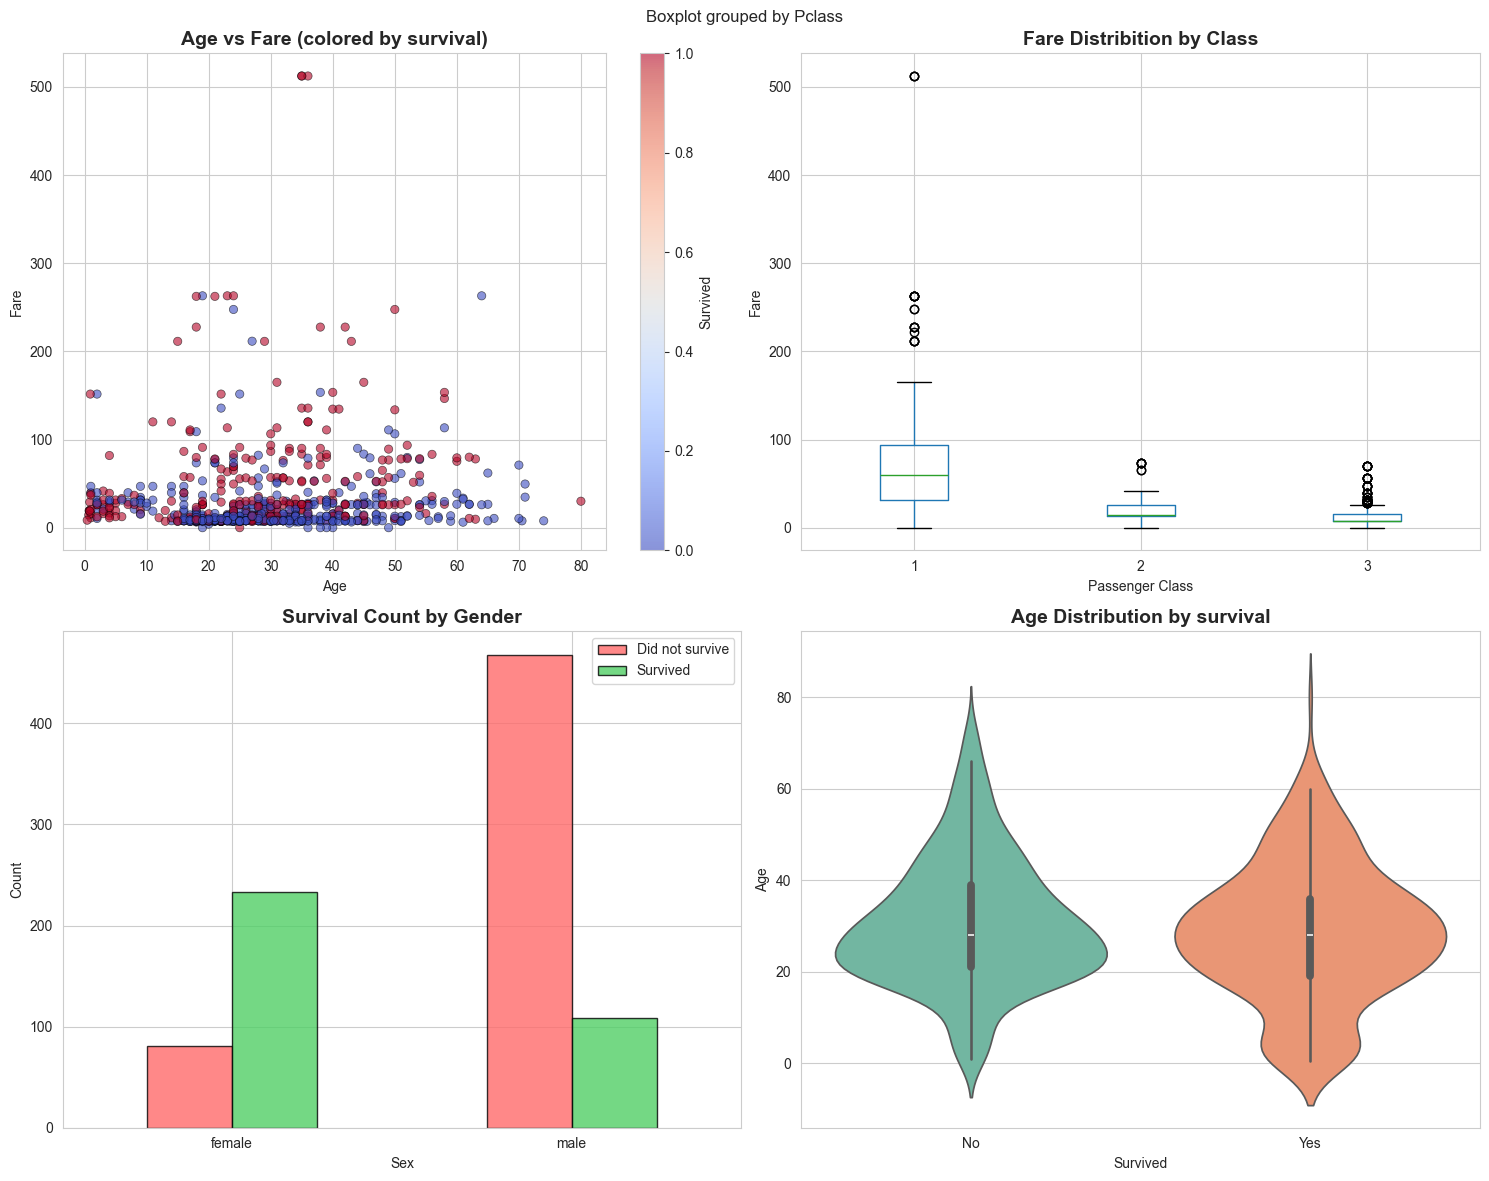

In [25]:
fig,axes = plt.subplots(2,2,figsize=(15,12))

## 2.1 Scatter Plot - Age vs Fare
scatter = axes[0,0].scatter(df['Age'], df['Fare'],c=df['Survived'], cmap='coolwarm',alpha=0.6,edgecolors='black',linewidth=0.5)
axes[0,0].set_xlabel("Age")
axes[0,0].set_ylabel("Fare")
axes[0,0].set_title("Age vs Fare (colored by survival)", fontsize=14, fontweight='bold')
cbar = plt.colorbar(scatter,ax=axes[0,0])
cbar.set_label("Survived")

# 2.2 Box Plot - Fare by Passenger Class
df.boxplot(column='Fare', by='Pclass', ax=axes[0,1])
axes[0,1].set_xlabel("Passenger Class")
axes[0,1].set_ylabel("Fare")
axes[0,1].set_title("Fare Distribition by Class", fontsize=14,fontweight='bold')
plt.sca(axes[0,1])
plt.xticks([1,2,3])

# 2.3 Grouped Bar Chart - Survival by Sex
survival_by_sex = pd.crosstab(df['Sex'],df['Survived'])
survival_by_sex.plot(kind='bar',ax=axes[1,0],color=['#ff6b6b','#51cf66'],edgecolor='black',alpha=0.8)
axes[1, 0].set_xlabel('Sex')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Survival Count by Gender', fontsize=14, fontweight='bold')
axes[1, 0].legend(['Did not survive', 'Survived'])
axes[1, 0].set_xticklabels(axes[1,0].get_xticklabels(),rotation=0)

# 2.4 violin Plot - Age distribution by Survival
sns.violinplot(data=df, x='Survived', y='Age', ax=axes[1,1], palette='Set2')
axes[1, 1].set_xlabel("Survived")
axes[1, 1].set_ylabel("Age")
axes[1, 1].set_title("Age Distribution by survival", fontsize=14, fontweight='bold')
axes[1, 1].set_xticklabels(["No","Yes"])

plt.tight_layout()


# 3. MULTIVARIATE ANALYSIS - Multiple Variables

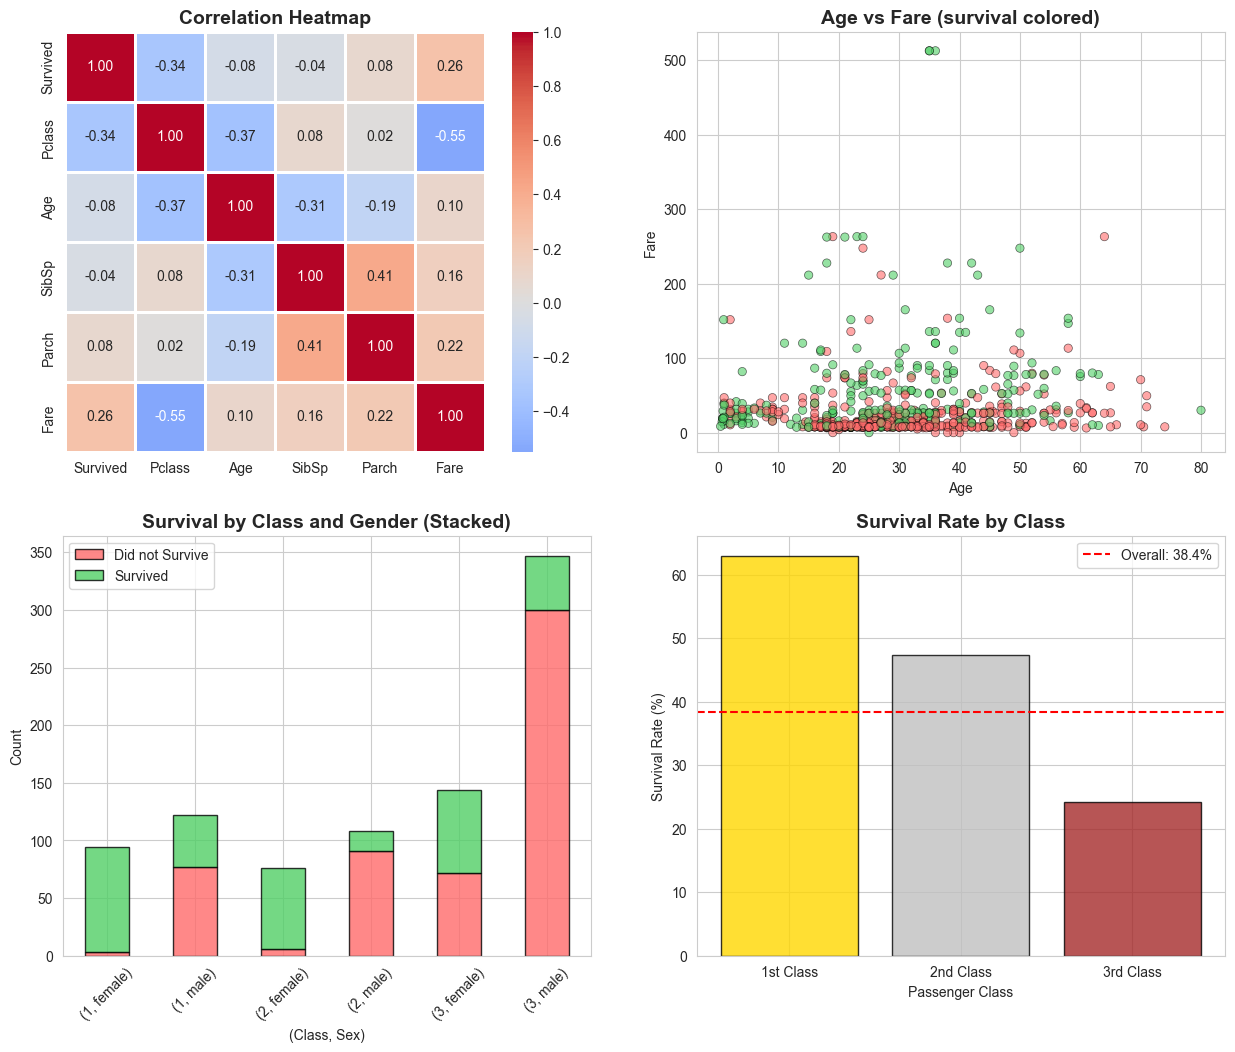

In [26]:
fig, axes = plt.subplots(2,2, figsize=(15,12))

# 3.1 Correlation Heatmap
correlation_matrix = df[['Survived','Pclass','Age','SibSp','Parch','Fare']].corr()
sns.heatmap(correlation_matrix,annot=True, fmt='.2f',cmap='coolwarm',center=0,ax=axes[0,0],square=True, linewidth=1)
axes[0, 0].set_title("Correlation Heatmap", fontsize=14, fontweight='bold')

# 3.2 Pair Plot style visualization - just a sample 
# Selecting key variables for pairplot visualization
numerical_cols = ['Age','Fare','SibSp']
sample_df = df[numerical_cols + ['Survived']].dropna()
colors = sample_df['Survived'].map({0: '#ff6b6b',1: '#51cf66'})

axes[0, 1].scatter(sample_df['Age'],sample_df['Fare'],c=colors,alpha=0.6, edgecolors='black',linewidth=0.5)
axes[0, 1].set_xlabel('Age')
axes[0, 1].set_ylabel('Fare')
axes[0, 1].set_title('Age vs Fare (survival colored)', fontsize=14, fontweight='bold')

# 3.3 Stacked Bar Chart - Survival by Class and Gender
survival_class_sex = pd.crosstab([df['Pclass'],df['Sex']],df['Survived'])
survival_class_sex.plot(kind='bar',stacked=True, ax=axes[1,0],  color=['#ff6b6b', '#51cf66'], edgecolor='black', alpha=0.8)
axes[1, 0].set_xlabel('(Class, Sex)')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Survival by Class and Gender (Stacked)', fontsize=14, fontweight='bold')
axes[1, 0].legend(['Did not Survive','Survived'])
axes[1, 0].tick_params(axis='x', rotation=45)

# 3.4 Grouped Bar Chart - Survival rate by Class
survival_rate_by_class = df.groupby('Pclass')['Survived'].mean()*100
x = np.arange(len(survival_rate_by_class))
axes[1, 1].bar(x, survival_rate_by_class.values,color=['gold','silver','brown'], edgecolor='black',alpha=0.8)
axes[1, 1].set_xlabel('Passenger Class')
axes[1, 1].set_ylabel('Survival Rate (%)')
axes[1, 1].set_title('Survival Rate by Class', fontsize=14, fontweight='bold')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(['1st Class', '2nd Class', '3rd Class'])
axes[1, 1].axhline(df['Survived'].mean() * 100, color='red', linestyle='--', 
                   label=f'Overall: {df["Survived"].mean()*100:.1f}%')
axes[1, 1].legend()



(0.0, 500.0)

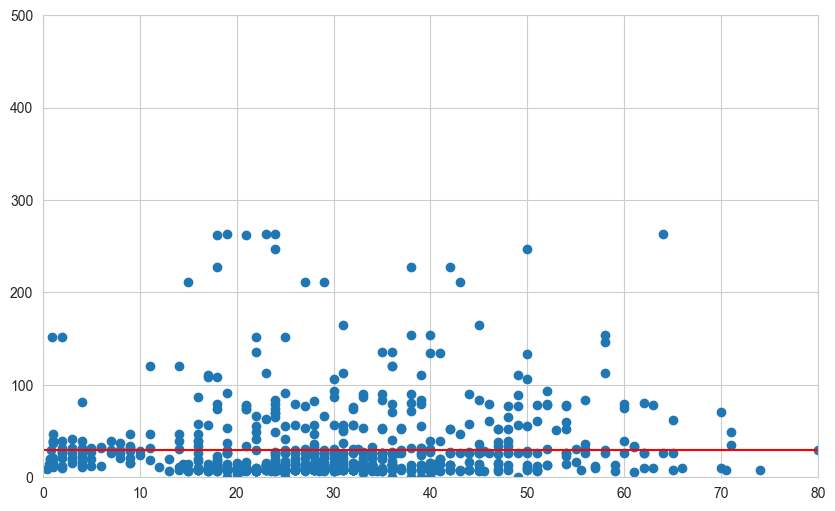

In [27]:
plt.figure(figsize=(10, 6))
plt.scatter(x=df['Age'], y=df['Fare'])
plt.plot([df['Age'].mean()]*len(df['Age']), color='red')
plt.xlim(right=80)
plt.xlim(left=0)
plt.ylim(top=500)
plt.ylim(bottom=0)

# 4. ADVANCED VISUALIZATION

(0.0, 112.07915)

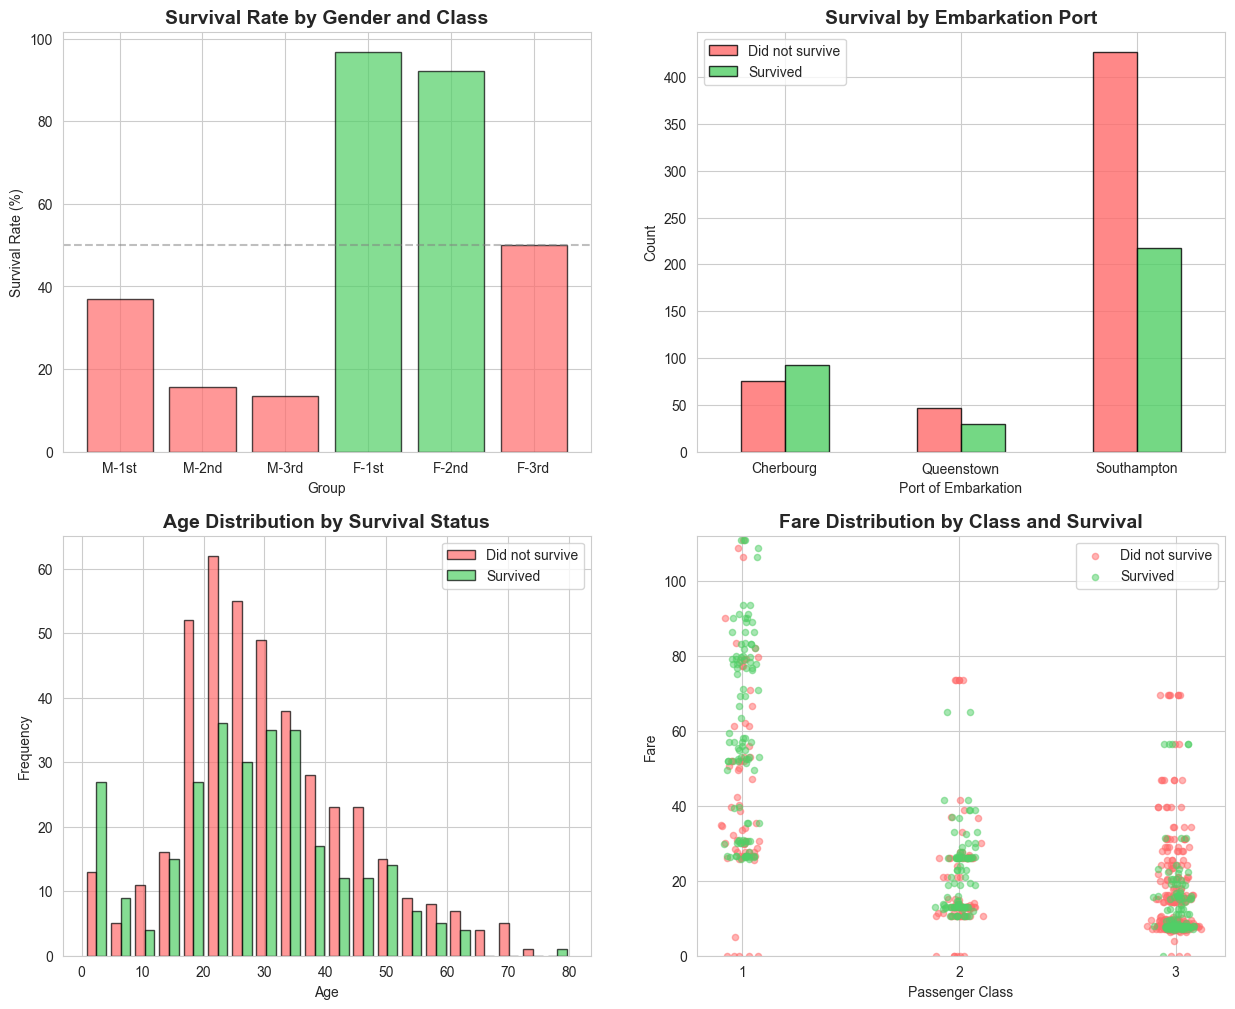

In [28]:
fig, axes = plt.subplots(2,2, figsize=(15,12))

# 4.1 FacetGrid style - Survival by multiple categories
for i, sex in enumerate(['male', 'female']):
    for j, pclass in enumerate([1,2,3]):
        subset =df[(df['Sex']== sex) & (df['Pclass'] == pclass)]
        if not subset.empty:
            survival_rate = subset['Survived'].mean()
            color = '#51cf66' if survival_rate > 0.5 else '#ff6b6b'
            axes[0, 0].bar(i * 3  + j, survival_rate * 100, color = color, edgecolor='black', alpha=0.7, width=0.8)

axes[0, 0].set_xlabel('Group')
axes[0, 0].set_ylabel('Survival Rate (%)')
axes[0, 0].set_title('Survival Rate by Gender and Class', fontsize=14, fontweight='bold')
axes[0, 0].set_xticks([0, 1, 2, 3, 4, 5])
axes[0, 0].set_xticklabels(['M-1st', 'M-2nd', 'M-3rd', 'F-1st', 'F-2nd', 'F-3rd'])
axes[0, 0].axhline(50, color='gray', linestyle='--', alpha=0.5)

# 4.2 Count Plot with Hue
embarked_df = df.dropna(subset=['Embarked'])
embarked_survival = pd.crosstab(embarked_df['Embarked'], embarked_df['Survived'])
embarked_survival.plot(kind='bar', ax=axes[0, 1], color=['#ff6b6b', '#51cf66'], 
                       edgecolor='black', alpha=0.8)
axes[0, 1].set_xlabel('Port of Embarkation')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Survival by Embarkation Port', fontsize=14, fontweight='bold')
axes[0, 1].legend(['Did not survive', 'Survived'])
axes[0, 1].set_xticklabels(['Cherbourg', 'Queenstown', 'Southampton'], rotation=0)

# 4.3 Distribution comparison - Age by survival
age_survived = df[df['Survived'] == 1]['Age'].dropna()
age_not_survived = df[df['Survived'] == 0]['Age'].dropna()

axes[1, 0].hist([age_not_survived, age_survived], bins=20, label=['Did not survive', 'Survived'],
                color=['#ff6b6b', '#51cf66'], alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('Age')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Age Distribution by Survival Status', fontsize=14, fontweight='bold')
axes[1, 0].legend()

# 4.4 Swarm/Strip Plot style - Fare by Class with Survival
for pclass in [1, 2, 3]:
    subset = df[df['Pclass'] == pclass]
    survived = subset[subset['Survived'] == 1]
    not_survived = subset[subset['Survived'] == 0]
    
    # Add jitter for visibility
    x_survived = np.random.normal(pclass, 0.04, size=len(survived))
    x_not_survived = np.random.normal(pclass, 0.04, size=len(not_survived))
    
    axes[1, 1].scatter(x_not_survived, not_survived['Fare'], alpha=0.5, 
                      color='#ff6b6b', s=20, label='Did not survive' if pclass == 1 else '')
    axes[1, 1].scatter(x_survived, survived['Fare'], alpha=0.5, 
                      color='#51cf66', s=20, label='Survived' if pclass == 1 else '')

axes[1, 1].set_xlabel('Passenger Class')
axes[1, 1].set_ylabel('Fare')
axes[1, 1].set_title('Fare Distribution by Class and Survival', fontsize=14, fontweight='bold')
axes[1, 1].set_xticks([1, 2, 3])
axes[1, 1].legend()
axes[1, 1].set_ylim(0, df['Fare'].quantile(0.95))  # Remove outliers for better viz


# 5. SEABORN SPECIFIC VISUALIZATIONS

C:\Users\raven\AppData\Local\Temp\ipykernel_34120\391095304.py:26: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Embarked', y='Fare', hue='Pclass', ax=axes[1, 1],


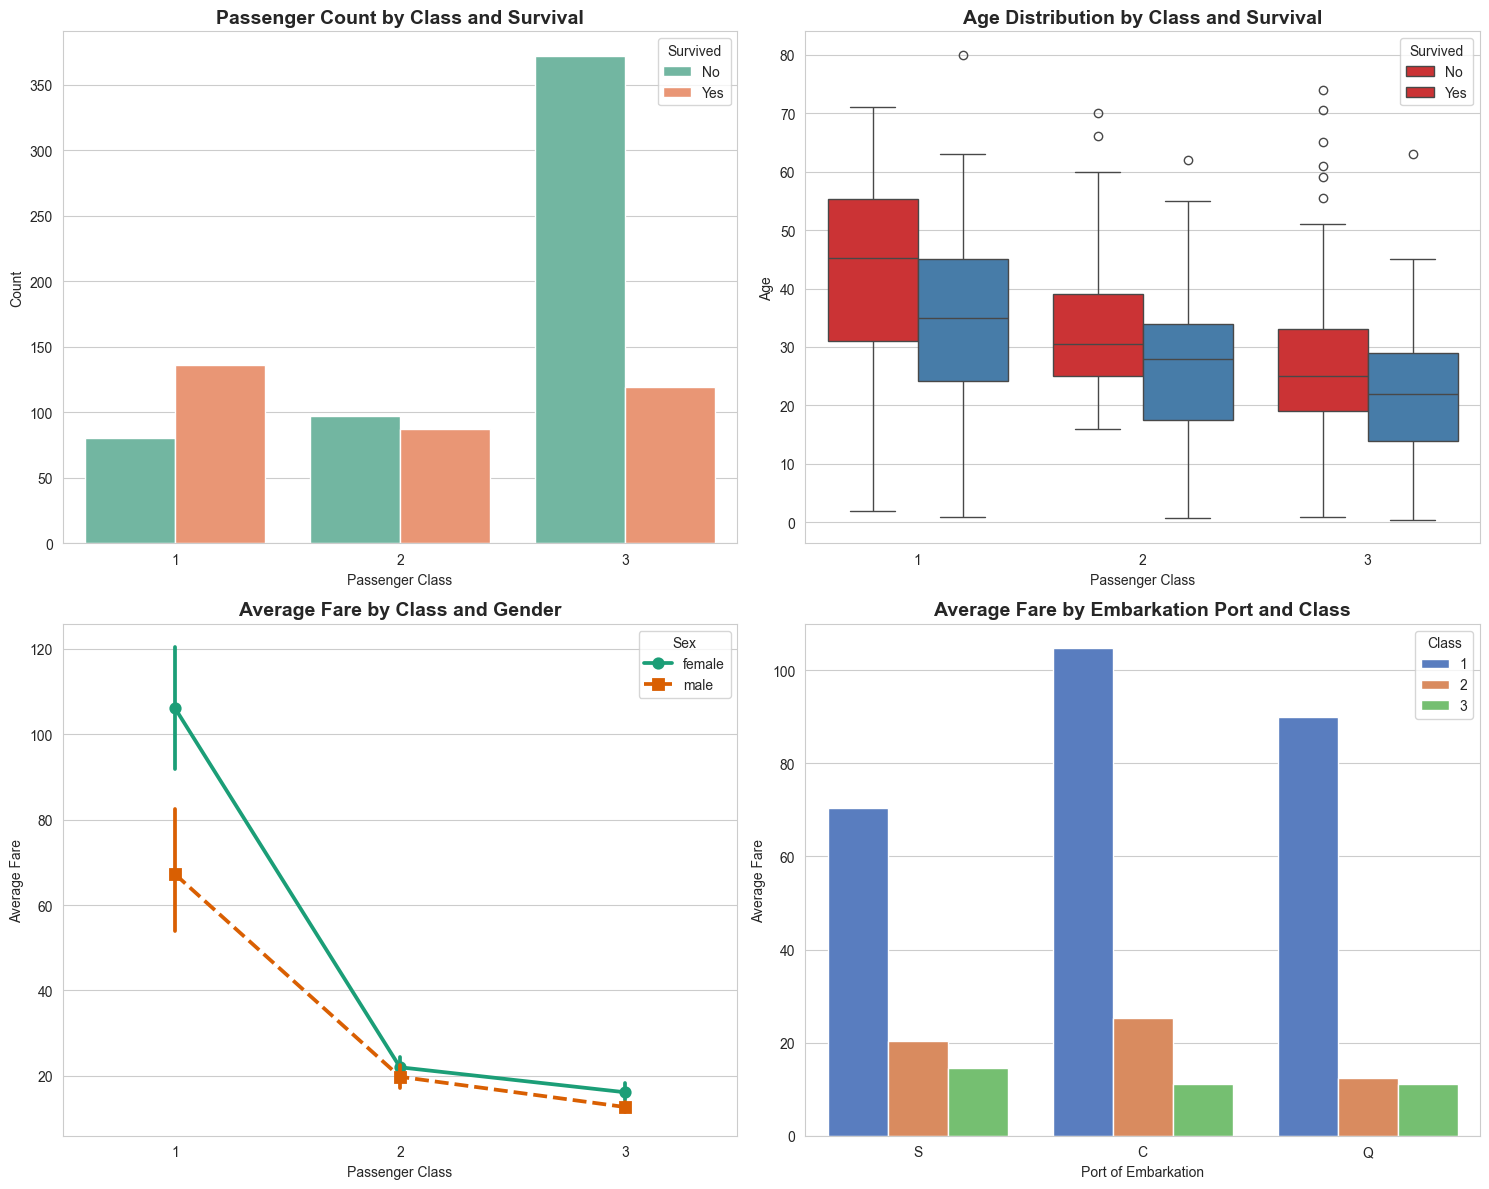

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 5.1 Count Plot
sns.countplot(data=df, x='Pclass', hue='Survived', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_xlabel('Passenger Class')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Passenger Count by Class and Survival', fontsize=14, fontweight='bold')
axes[0, 0].legend(title='Survived', labels=['No', 'Yes'])

# 5.2 Box Plot with Seaborn
sns.boxplot(data=df, x='Pclass', y='Age', hue='Survived', ax=axes[0, 1], palette='Set1')
axes[0, 1].set_xlabel('Passenger Class')
axes[0, 1].set_ylabel('Age')
axes[0, 1].set_title('Age Distribution by Class and Survival', fontsize=14, fontweight='bold')
axes[0, 1].legend(title='Survived', labels=['No', 'Yes'])

# 5.3 Point Plot - Shows mean and confidence interval
sns.pointplot(data=df, x='Pclass', y='Fare', hue='Sex', ax=axes[1, 0], 
              palette='Dark2', markers=['o', 's'], linestyles=['-', '--'])
axes[1, 0].set_xlabel('Passenger Class')
axes[1, 0].set_ylabel('Average Fare')
axes[1, 0].set_title('Average Fare by Class and Gender', fontsize=14, fontweight='bold')
axes[1, 0].legend(title='Sex')

# 5.4 Bar Plot with Seaborn (shows mean)
sns.barplot(data=df, x='Embarked', y='Fare', hue='Pclass', ax=axes[1, 1], 
            palette='muted', ci=None)
axes[1, 1].set_xlabel('Port of Embarkation')
axes[1, 1].set_ylabel('Average Fare')
axes[1, 1].set_title('Average Fare by Embarkation Port and Class', fontsize=14, fontweight='bold')
axes[1, 1].legend(title='Class')

plt.tight_layout()

# 6. STATISTICAL VISUALIZATIONS

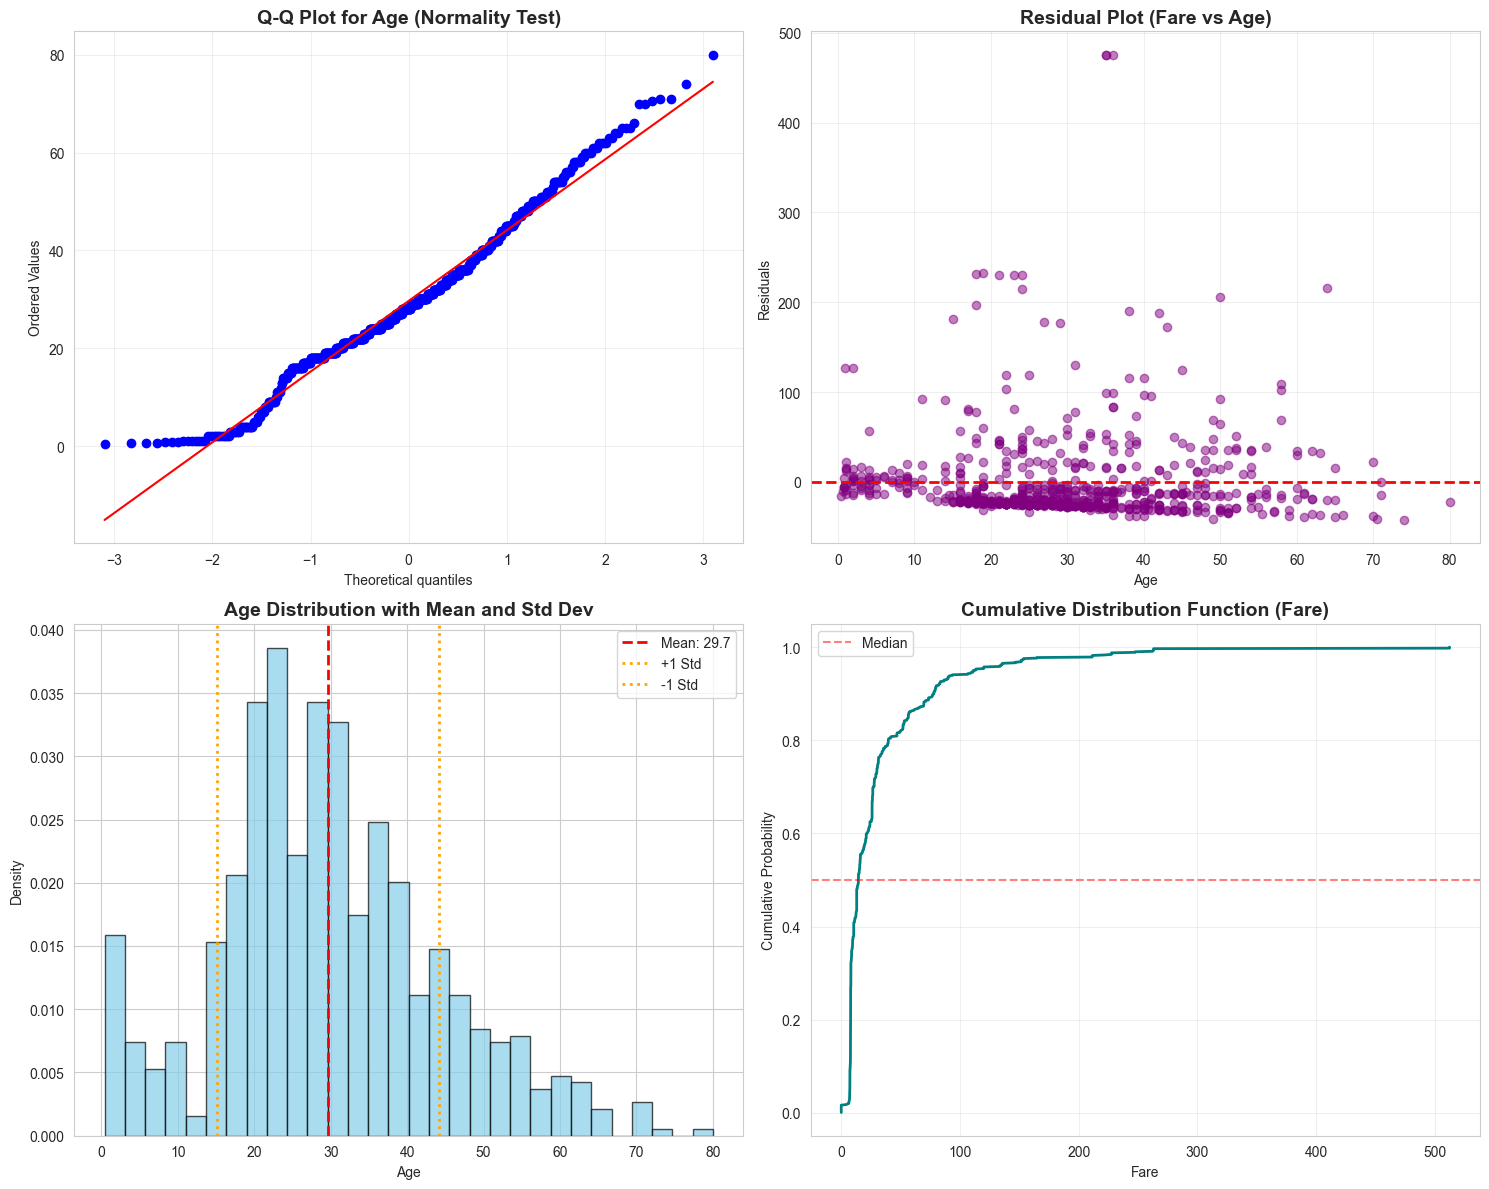

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 6.1 Q-Q Plot for normality test
stats.probplot(df['Age'].dropna(), dist="norm", plot=axes[0, 0])
axes[0, 0].set_title('Q-Q Plot for Age (Normality Test)', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 6.2 Residual Plot concept
# Simple example: Fare vs Age with fitted line
clean_df = df[['Age', 'Fare']].dropna()
z = np.polyfit(clean_df['Age'], clean_df['Fare'], 1)
p = np.poly1d(z)
predicted = p(clean_df['Age'])
residuals = clean_df['Fare'] - predicted

axes[0, 1].scatter(clean_df['Age'], residuals, alpha=0.5, color='purple')
axes[0, 1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Age')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Residual Plot (Fare vs Age)', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 6.3 Distribution with Mean and Std
age_data = df['Age'].dropna()
mean_age = age_data.mean()
std_age = age_data.std()

axes[1, 0].hist(age_data, bins=30, density=True, alpha=0.7, color='skyblue', edgecolor='black')
axes[1, 0].axvline(mean_age, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_age:.1f}')
axes[1, 0].axvline(mean_age + std_age, color='orange', linestyle=':', linewidth=2, label=f'+1 Std')
axes[1, 0].axvline(mean_age - std_age, color='orange', linestyle=':', linewidth=2, label=f'-1 Std')
axes[1, 0].set_xlabel('Age')
axes[1, 0].set_ylabel('Density')
axes[1, 0].set_title('Age Distribution with Mean and Std Dev', fontsize=14, fontweight='bold')
axes[1, 0].legend()

# 6.4 Cumulative Distribution Function
sorted_fare = np.sort(df['Fare'].dropna())
cumulative = np.arange(1, len(sorted_fare) + 1) / len(sorted_fare)

axes[1, 1].plot(sorted_fare, cumulative, linewidth=2, color='teal')
axes[1, 1].set_xlabel('Fare')
axes[1, 1].set_ylabel('Cumulative Probability')
axes[1, 1].set_title('Cumulative Distribution Function (Fare)', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Median')
axes[1, 1].legend()

plt.tight_layout()